# 1.Introducció
En aquesta pràctica analitzarem un dataset de monstres de Dungeons & Dragons 5a edició amb l'objectiu de predir el Challenge Rating (CR) utilitzant diferents atributs i el model KNN, que és un model molt senzill que, basant-se en la proximitat, prediu els valors de noves dades basant-se en la majoria de vots dels seus _k_ veins més propers en el conjunt d'entrenament.

# 2. Càrrega i exploració del dataset

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [132]:
df = pd.read_csv("dnd_monsters.csv")
df = df[["name", "cr", "ac", "hp", "str", "dex"]] # Potser això hauria d'estar al punt de la preparació de dades, però he volgut treure d'enmig dades irrelevants des del principi.
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    761 non-null    str    
 1   cr      761 non-null    str    
 2   ac      761 non-null    int64  
 3   hp      761 non-null    int64  
 4   str     401 non-null    float64
 5   dex     401 non-null    float64
dtypes: float64(2), int64(2), str(2)
memory usage: 35.8 KB


,name,cr,ac,hp,str,dex
0,aarakocra,1/4,12,13,10.0,14.0
1,abjurer,9,12,84,NaN,NaN
2,aboleth,10,17,135,21.0,9.0
3,abominable-yeti,9,15,137,NaN,NaN
4,acererak,23,21,285,NaN,NaN


# 3. Preparació de dades
El CR és un número que va de 0 a 30, i KNN classifica millor amb poques categories, així que classificarem els monstres segons si el seu CR és baix, promig, alt o molt alt.

In [133]:
def cr_category(cr):
    if cr <= 1:
        return "Low"
    elif cr <= 5:
        return "Medium"
    elif cr <= 10:
        return "High"
    else:
        return "Very High"
    
def parse_cr(cr): # Necessària perquè hi ha CR expressats en fracció al Dataset
    if isinstance(cr, str) and "/" in cr:
        num, den = cr.split("/")
        return float(num) / float(den)
    return float(cr)


df["cr"] = df["cr"].apply(parse_cr) # Convertim de String a Float
print(f"CRs abans de discretitzar: {df["cr"].unique()}")
df["CR"] = pd.Categorical(
    df["cr"].apply(cr_category),
    categories=["Low", "Medium", "High", "Very High"],
    ordered=True
)
print(f"CRs després de discretitzar: {df["CR"].unique()}")


CRs abans de discretitzar: [ 0.25   9.    10.    23.    14.    17.    16.    13.    15.     2.
  5.     7.    11.     0.5   18.    21.    20.    22.    24.     1.
  3.     6.    12.     8.     0.     4.    19.     0.125 26.    25.
 30.   ]
CRs després de discretitzar: ['Low', 'High', 'Very High', 'Medium']
Categories (4, str): ['Low' < 'Medium' < 'High' < 'Very High']


# 4. Model 1 - Dos atributs
En aquest primer model s'utilitzen dos atributs bàsics relacionats amb la resistència del monstre: la Classe d'Armadura i els Punts de Vida.

In [134]:
features = ["ac", "hp"]
X = df[features]
y = df["CR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))

Train accuracy: 0.8515037593984962
Test accuracy: 0.759825327510917


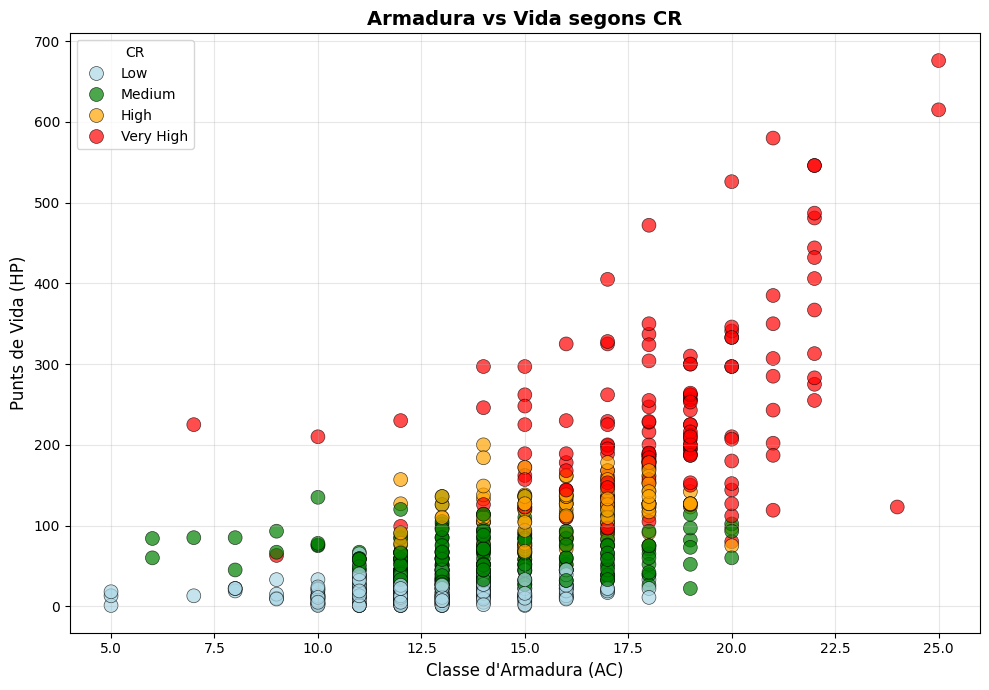

In [135]:
# Define custom color palette for CR categories
cr_palette = {"Low": "lightblue", "Medium": "green", "High": "orange", "Very High": "red"}

# Generem Gràfica
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df["ac"],
    y=df["hp"],
    hue=df["CR"],
    palette=cr_palette,
    s=100,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)
plt.title("Armadura vs Vida segons CR", fontsize=14, fontweight='bold')
plt.xlabel("Classe d'Armadura (AC)", fontsize=12)
plt.ylabel("Punts de Vida (HP)", fontsize=12)
plt.legend(title="CR", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 5. Model 2 - Dos atributs diferents
En aquest segon experiment compararem les característiques físiques del monstre amb la CR.

Train accuracy: 0.7392857142857143
Test accuracy: 0.6198347107438017


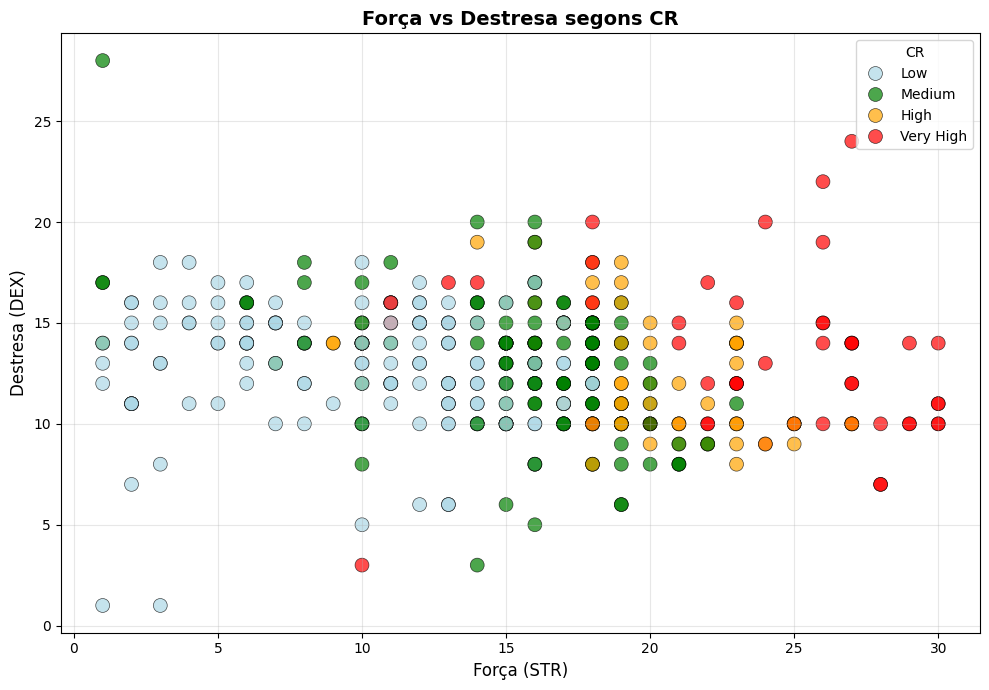

In [136]:
features_2 = ["str", "dex"]
X = df[features_2].dropna()
y = df.loc[X.index, "CR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))

# Generem Gràfica
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df.loc[X.index, "str"],
    y=df.loc[X.index, "dex"],
    hue=df.loc[X.index, "CR"],
    palette=cr_palette,
    s=100,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)
plt.title("Força vs Destresa segons CR", fontsize=14, fontweight='bold')
plt.xlabel("Força (STR)", fontsize=12)
plt.ylabel("Destresa (DEX)", fontsize=12)
plt.legend(title="CR", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 6. Model 3 - Tres atributs
Finalment, farem una comparació de tres atributs amb la CR per veure si millorem el rendiment del model.

Train accuracy: 0.8642857142857143
Test accuracy: 0.7520661157024794


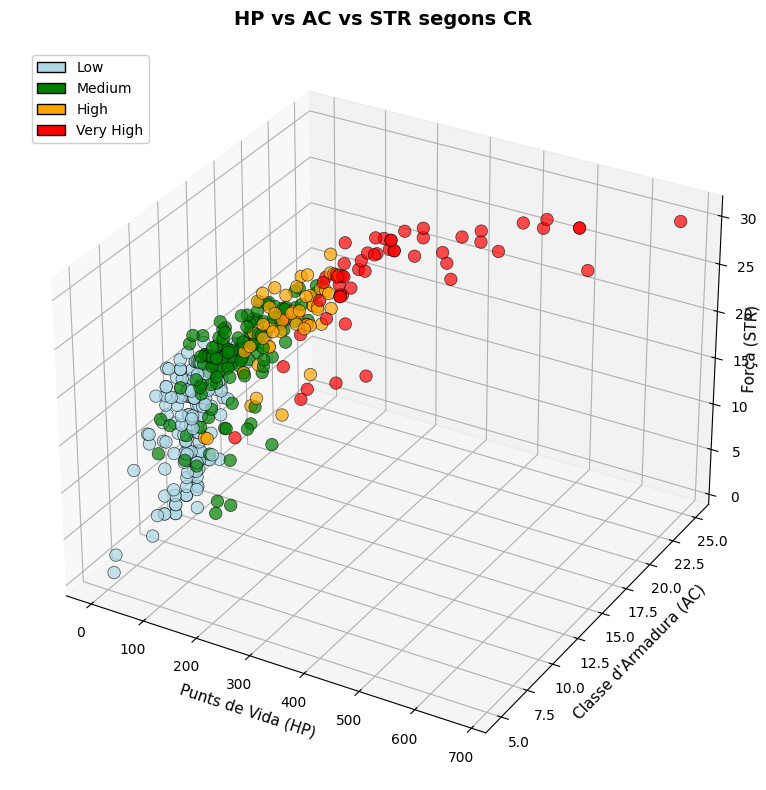

In [137]:
from mpl_toolkits.mplot3d import Axes3D

features_3 = ["hp", "ac", "str"]
X = df[features_3].dropna()
y = df.loc[X.index, "CR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))

# 3D scatter plot
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# Create color mapping
color_map = {"Low": "lightblue", "Medium": "green", "High": "orange", "Very High": "red"}
colors = [color_map[cr] for cr in df.loc[X.index, "CR"]]

ax.scatter(df.loc[X.index, "hp"], df.loc[X.index, "ac"], df.loc[X.index, "str"], 
           c=colors, alpha=0.7, s=80, edgecolor='black', linewidth=0.5)

ax.set_xlabel("Punts de Vida (HP)", fontsize=11)
ax.set_ylabel("Classe d'Armadura (AC)", fontsize=11)
ax.set_zlabel("Força (STR)", fontsize=11, labelpad=-5)
ax.set_title("HP vs AC vs STR segons CR", fontsize=14, fontweight='bold')

# Create legend with proper placement
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cat], edgecolor='black', label=cat) 
                   for cat in ["Low", "Medium", "High", "Very High"]]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, bbox_to_anchor=(0.02, 0.98), framealpha=0.95)

plt.tight_layout()
plt.show()


# 7. Anàlisi de paràmetres

- Percentatge train-test

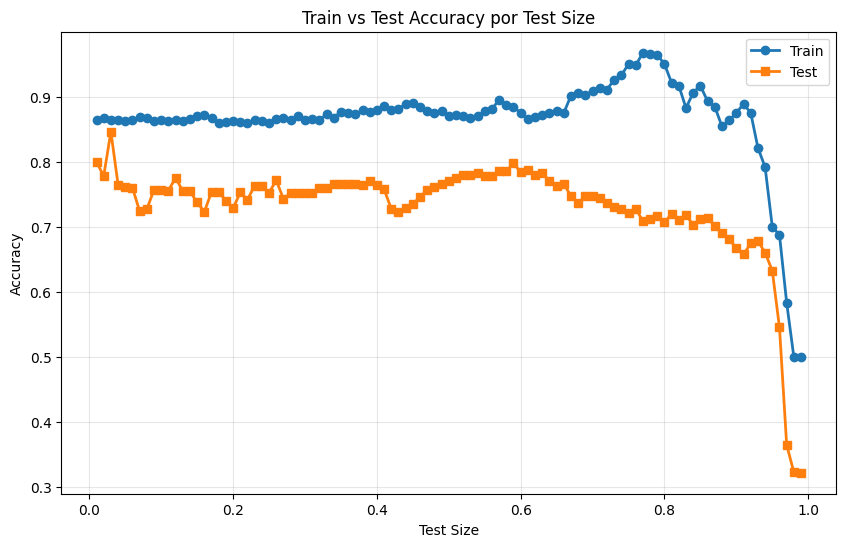

In [148]:
test_sizes = [x * 0.01 for x in range(1, 100)]
train_acc = []
test_acc = []

for test_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(n_neighbors=4)
    knn.fit(X_train_scaled, y_train)
    
    y_pred_train = knn.predict(X_train_scaled)
    y_pred_test = knn.predict(X_test_scaled)
    
    train_acc.append(accuracy_score(y_train, y_pred_train))
    test_acc.append(accuracy_score(y_test, y_pred_test))
    
    #print(f"Train accuracy with test_size={test_size}:", train_acc[-1])
    #print(f"Test accuracy with test_size={test_size}:", test_acc[-1])

# Plot train and test accuracy vs test_size
plt.figure(figsize=(10, 6))
plt.plot(test_sizes, train_acc, marker='o', label="Train", linewidth=2)
plt.plot(test_sizes, test_acc, marker='s', label="Test", linewidth=2)
plt.xlabel("Test Size")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy por Test Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


- Canviant n_neighbors

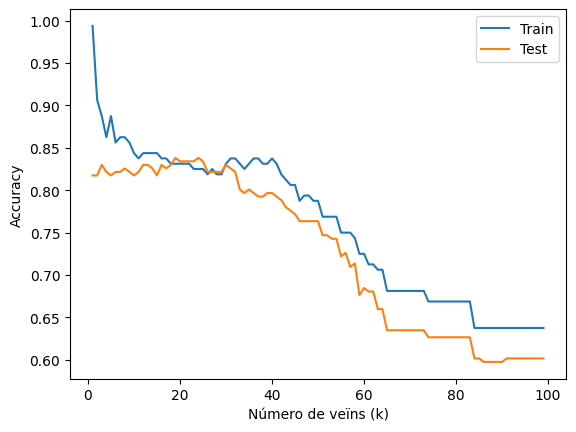

In [149]:
k_values = range(1, 100)
train_acc = []
test_acc = []
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.6, random_state=42
    )


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

plt.plot(k_values, train_acc, label="Train")
plt.plot(k_values, test_acc, label="Test")
plt.xlabel("Número de veïns (k)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Conclusió
Com podem observar, segons augmenta el número de veïns (k), la precisió disminueix dràsticament. Sembla ser que el "sweet spot" sembla estar entre els 20 i els 30 veïns, ja que és la part on veiem que la test accuracy queda per sobre de la train accuracy. Menys de 10 veïns ens dona una precisió massa alta (overfitting), i a partir dels 40 ens baixa la precisió en picat (underfitting).

Els experiments mostren que els atributs relacionats amb la resistència del monstre (HP, AC) tenen més pes en la predicció del CR que els atributs de força i destresa.
L’ús de més atributs millora lleugerament l’accuracy, però com que la força i la destresa tenen tan poca relació amb la CR, l'augment és marginal. A part, tenim més de 700 monstres amb vida i armadura, però només 400 amb força i destresa definides. Crec que això és a causa de la poca importància que tenen aquestes i altres característiques de la fitxa dels monstres a l'hora de lluitar contra ells, ja que normalment aquestes característiques només s'utilitzen per la part de roleig i pocs cops es juga amb un monstre.

Finalment, el requirements.txt ha sigut generat amb pipreqs.

Com a nota honesta, i a manera de carta pel professor, he començat aquest curs amb molt poca motivació, i he iniciat aquesta pràctica amb moltes menys ganes que en acabar-la.
La meva intenció era cantar la nadala de la IA i a una altra cosa, però entre la oportunitat de visualitzar dades sobre un tema que m'agrada i la curiositat que m'han generat les gràfiques mostrant coses estranyes, he acabat donant-li molt més mimo a aquesta pràctica del que m'esperava.

Primer, el nostre amic i veí ChatGPT no havia tingut en compte els següents punts sobre el dataset:
- 1. Algunes CR estan representades com a fracció, la qual cosa feia impossible classificar-les de manera numèrica sense cap conversió prèvia
- 2. Com que les CR van de 0 a 30, em donava una test accuracy de 0 sempre. Això m'ha semblat estrany, així que investigant he trobat que el model KNN dona millors resultats com menys "categories" hagi de classificar, així que he reduït de 30+ categories a només 4, i he aconseguit augmentar la precisió.

Finalment, quan he adaptat les dades perquè les anàlisis siguin correctes, he patit intentant interpretar-les als plots, així que he dedicat bastanta estona a estilitzar les gràfiques i fins i tot trobar-ne de noves (3D scatter per la comparació amb 3 features), encara que amb una mica d'ajut artificialment intel·ligent.